<a href="https://colab.research.google.com/github/MuhammadAqsandy/scikit-learn-cookbook/blob/main/chapter_06_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Advanced Logistic Regression
## 📌 Summary
Logistic Regression adalah classifier linear yang menggunakan **sigmoid function** untuk menghasilkan probabilitas. Meski namanya 'regression', ini adalah **classifier**.

## 🧠 Theoretical Deep-Dive

### 6.1 Logistic Function (Sigmoid)
σ(z) = 1 / (1 + e⁻ᶻ)  dimana z = w·x + b

Output adalah probabilitas P(y=1|x). Threshold default = 0.5

### 6.2 Loss Function: Cross-Entropy
Logistic Regression meminimalkan **binary cross-entropy**:
L = -[y·log(p) + (1-y)·log(1-p)]

### 6.3 Regularization
- **C = 1/α**: berbeda dengan Ridge/Lasso! C kecil → regularisasi kuat
- `penalty='l1'`: sparse solution
- `penalty='l2'`: default, selalu prefer

### 6.4 Multiclass Strategies
- **One-vs-Rest (OvR)**: buat satu classifier per class vs semua class lain
- **Multinomial (Softmax)**: satu classifier untuk semua class sekaligus

### 6.5 Class Imbalance
`class_weight='balanced'` otomatis menyesuaikan bobot class berdasarkan frekuensi.

## 💻 Code Reproduction

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(C=1.0, penalty="l2", max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

print("Accuracy:", round(lr.score(X_test_s, y_test), 4))
print("\nClassification Report:")
print(classification_report(y_test, lr.predict(X_test_s)))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr.predict(X_test_s)))

Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[41  2]
 [ 1 70]]


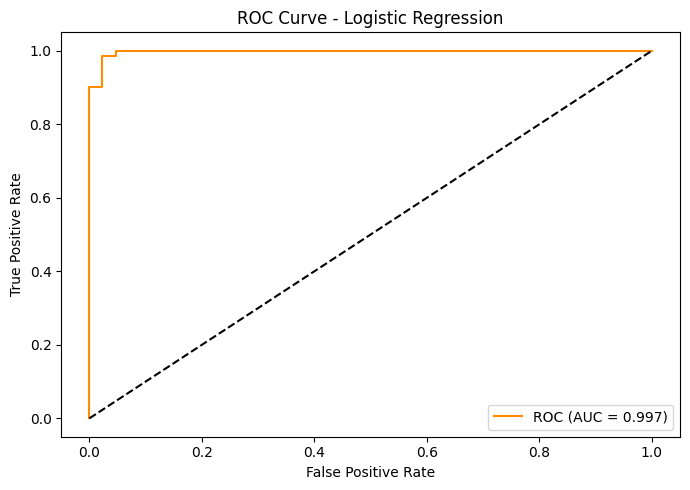

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

y_proba = lr.predict_proba(X_test_s)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(); plt.tight_layout(); plt.show()

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    for penalty in ["l1", "l2"]:
        solver = "liblinear" if penalty == "l1" else "lbfgs"
        lr = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
        lr.fit(X_train_s, y_train)
        n_zero = np.sum(lr.coef_[0] == 0) if penalty=="l1" else 0
        print(f"C={C:6}, penalty={penalty}: acc={lr.score(X_test_s, y_test):.4f}, zero_coefs={n_zero}")

C= 0.001, penalty=l1: acc=0.3772, zero_coefs=30
C= 0.001, penalty=l2: acc=0.8860, zero_coefs=0
C=  0.01, penalty=l1: acc=0.9649, zero_coefs=27
C=  0.01, penalty=l2: acc=0.9649, zero_coefs=0
C=   0.1, penalty=l1: acc=0.9649, zero_coefs=22
C=   0.1, penalty=l2: acc=0.9825, zero_coefs=0
C=   1.0, penalty=l1: acc=0.9737, zero_coefs=15
C=   1.0, penalty=l2: acc=0.9737, zero_coefs=0
C=  10.0, penalty=l1: acc=0.9561, zero_coefs=8
C=  10.0, penalty=l2: acc=0.9737, zero_coefs=0
C= 100.0, penalty=l1: acc=0.9386, zero_coefs=4
C= 100.0, penalty=l2: acc=0.9386, zero_coefs=0


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# OvR vs Multinomial
# Note: multi_class param deprecated in sklearn 1.5+ -> use OneVsRestClassifier

# OvR explicitly
ovr = OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=1000))
ovr.fit(X_train_s, y_train)
print(f"OneVsRest       : acc={ovr.score(X_test_s, y_test):.4f}")

# Multinomial (default lbfgs behavior for multiclass)
lr_multi = LogisticRegression(solver="lbfgs", max_iter=1000)
lr_multi.fit(X_train_s, y_train)
print(f"Multinomial(def): acc={lr_multi.score(X_test_s, y_test):.4f}")

print("\nClassification Report (Multinomial):")
print(classification_report(y_test, lr_multi.predict(X_test_s), target_names=["setosa","versicolor","virginica"]))

OneVsRest       : acc=0.9667
Multinomial(def): acc=1.0000

Classification Report (Multinomial):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

# Imbalanced dataset
X, y = make_classification(n_samples=1000, n_features=10, weights=[0.9, 0.1], random_state=42)
print("Class distribution:", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for cw in [None, "balanced"]:
    lr = LogisticRegression(class_weight=cw, max_iter=1000)
    lr.fit(X_train_s, y_train)
    print(f"\nclass_weight={cw}:")
    print(classification_report(y_test, lr.predict(X_test_s)))

Class distribution: [897 103]

class_weight=None:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       179
           1       0.67      0.48      0.56        21

    accuracy                           0.92       200
   macro avg       0.80      0.72      0.76       200
weighted avg       0.91      0.92      0.91       200


class_weight=balanced:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94       179
           1       0.53      1.00      0.69        21

    accuracy                           0.91       200
   macro avg       0.76      0.95      0.82       200
weighted avg       0.95      0.91      0.92       200



## ✅ Chapter Summary
- Logistic Regression outputnya **probabilitas** via sigmoid
- **C** adalah inverse regularization strength (C=1/α): C kecil → regularisasi kuat
- **ROC-AUC** lebih baik dari accuracy untuk evaluasi, terutama data imbalance
- `multi_class='multinomial'` + `solver='lbfgs'` → best untuk multiclass
- `class_weight='balanced'` penting untuk imbalanced datasets
- Cek calibration probabilitas dengan `predict_proba()` jika model akan digunakan untuk thresholding